# Old-data baseline overview

This notebook keeps the validated baseline workflow in view. The active data source is the archived CEDS files in `data/SLCF_main/old/`, and the analysis is intentionally focused on that reference dataset before moving to the new production release.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from slcf_forcings.ceds import annual_global_totals, discover_emissions_files, load_cell_area

DATA_DIR = PROJECT_ROOT / "data" / "SLCF_main" / "old"
print(f"Project root: {PROJECT_ROOT}")
print(f"Old-data directory: {DATA_DIR}")


Project root: /Users/assengu/Documents/projects/side05_cmip_feoc_forcings_slfc_evaluation
Old-data directory: /Users/assengu/Documents/projects/side05_cmip_feoc_forcings_slfc_evaluation/data/SLCF_main/old


In [2]:
all_species = ["BC", "CH4", "CO", "CO2", "N2O", "NH3", "NMVOC", "NOx", "OC", "SO2"]
files = [
    path for path in discover_emissions_files(DATA_DIR)
    if "-em-anthro_" in path.name
    and "200001-202312" in path.name
    and path.name.split("-em-", maxsplit=1)[0] in all_species
]
print(f"Files selected for baseline: {len(files)}")
for path in files:
    print(path.name)


Files selected for baseline: 8
BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
CO-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
CO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
NH3-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
NMVOC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
NOx-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
OC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
SO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc


In [3]:
cell_area = load_cell_area(DATA_DIR)
annual = annual_global_totals(files, cell_area)
annual["species_variable"] = annual["species_variable"].str.replace("_em_anthro", "")
annual = annual.rename(columns={"tg_per_year": "tg_yr"})

global_totals = (
    annual.groupby(["year", "species_variable"], as_index=False)["tg_yr"].sum()
    .sort_values(["species_variable", "year"])
)
print(global_totals[global_totals["year"].isin([2000, 2010, 2020, 2023])].to_string(index=False))


Aggregating CEDS files:   0%|          | 0/8 [00:00<?, ?file/s]

 year species_variable        tg_yr
 2000               BC     5.470301
 2010               BC     6.142493
 2020               BC     5.193855
 2023               BC     5.253859
 2000               CO   540.919554
 2010               CO   507.119233
 2020               CO   412.445495
 2023               CO   409.663127
 2000              CO2 25083.939345
 2010              CO2 33034.350257
 2020              CO2 35142.304489
 2023              CO2 37766.109921
 2000              NH3    49.800028
 2010              NH3    55.916782
 2020              NH3    62.243462
 2023              NH3    64.118406
 2000            NMVOC   114.459656
 2010            NMVOC   123.814598
 2020            NMVOC   125.447065
 2023            NMVOC   127.982492
 2000              NOx   112.797527
 2010              NOx   119.342521
 2020              NOx   100.101471
 2023              NOx   103.495235
 2000               OC    11.803904
 2010               OC    13.384153
 2020               OC    12

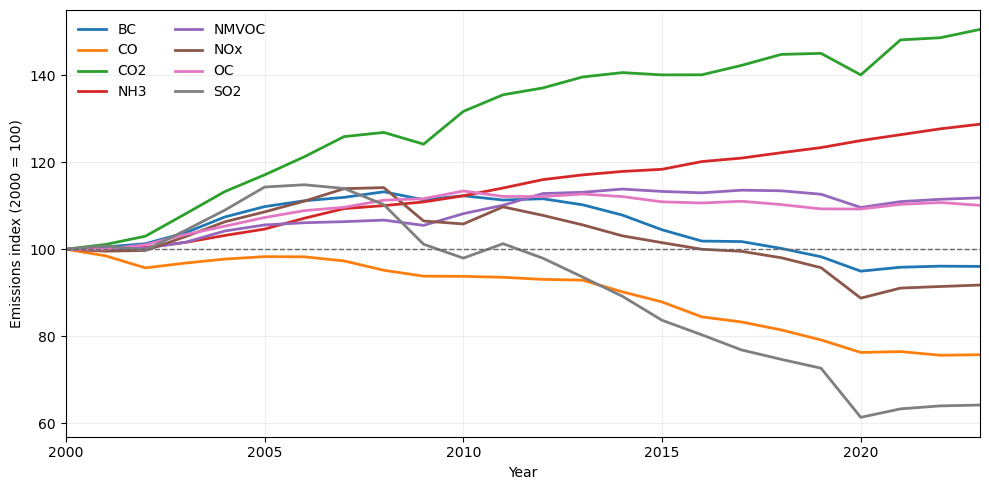

In [4]:
series = global_totals.pivot(index="year", columns="species_variable", values="tg_yr")
normalized = series.divide(series.loc[2000]).mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
for column in normalized.columns:
    ax.plot(normalized.index, normalized[column], linewidth=2, label=column)
ax.axhline(100, color="0.4", linestyle="--", linewidth=1)
ax.set(xlabel="Year", ylabel="Emissions index (2000 = 100)", xlim=(2000, 2023))
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


## Lightweight archive overview

The raw CEDS archive is large, so this section uses a reduced but representative species set to show the historical structure without repeating the full gridded calculation for every species in every notebook pass. The goal is a quick overview of the long-run pattern, not a full reprocessing of the complete archive on demand.


In [11]:
# Build a lighter long-run overview for the species that drive the working baseline.
# This keeps the notebook responsive while still showing the historical shape of the archive.
overview_species = ["BC", "CH4", "CO", "CO2", "N2O", "NH3", "NMVOC", "NOx", "OC", "SO2"]
overview_files = [
    path for path in discover_emissions_files(DATA_DIR)
    if "-em-anthro_" in path.name
    and path.name.split("-em-", maxsplit=1)[0] in overview_species
]

overview_annual = annual_global_totals(overview_files, cell_area)
overview_annual["species_variable"] = overview_annual["species_variable"].str.replace("_em_anthro", "")
overview_annual = overview_annual.rename(columns={"tg_per_year": "tg_yr"})

overview_global = (
    overview_annual.groupby(["year", "species_variable"], as_index=False)["tg_yr"].sum()
    .sort_values(["species_variable", "year"])
)
overview_series = overview_global.pivot(index="year", columns="species_variable", values="tg_yr")

print(f"Overview years: {int(overview_annual['year'].min())} to {int(overview_annual['year'].max())}")
print(f"Species in overview: {list(overview_series.columns)}")
print(overview_annual.head().to_string(index=False))


Aggregating CEDS files:   0%|          | 0/52 [00:00<?, ?file/s]

Overview years: 1750 to 2023
Species in overview: ['BC', 'CH4', 'CO', 'CO2', 'N2O', 'NH3', 'NMVOC', 'NOx', 'OC', 'SO2']
 sector    tg_yr species_variable                                                                     source_file  year
      0 0.000000               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_175001-179912.nc  1750
      1 0.000067               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_175001-179912.nc  1750
      2 0.008764               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_175001-179912.nc  1750
      3 0.000000               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_175001-179912.nc  1750
      4 0.528009               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_175001-179912.nc  1750


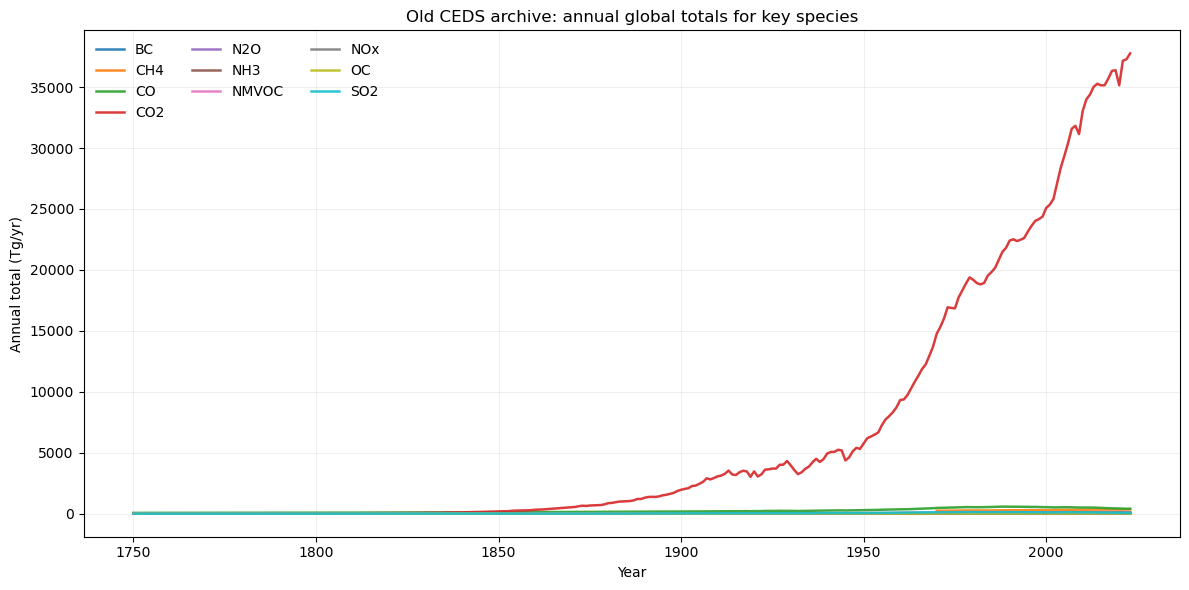

In [12]:
# Plot 1: representative archive annual totals for the key working species
fig, ax = plt.subplots(figsize=(12, 6))
for column in overview_series.columns:
    ax.plot(overview_series.index, overview_series[column], linewidth=1.8, alpha=0.9, label=column)
ax.set_title("Old CEDS archive: annual global totals for key species")
ax.set_xlabel("Year")
ax.set_ylabel("Annual total (Tg/yr)")
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()


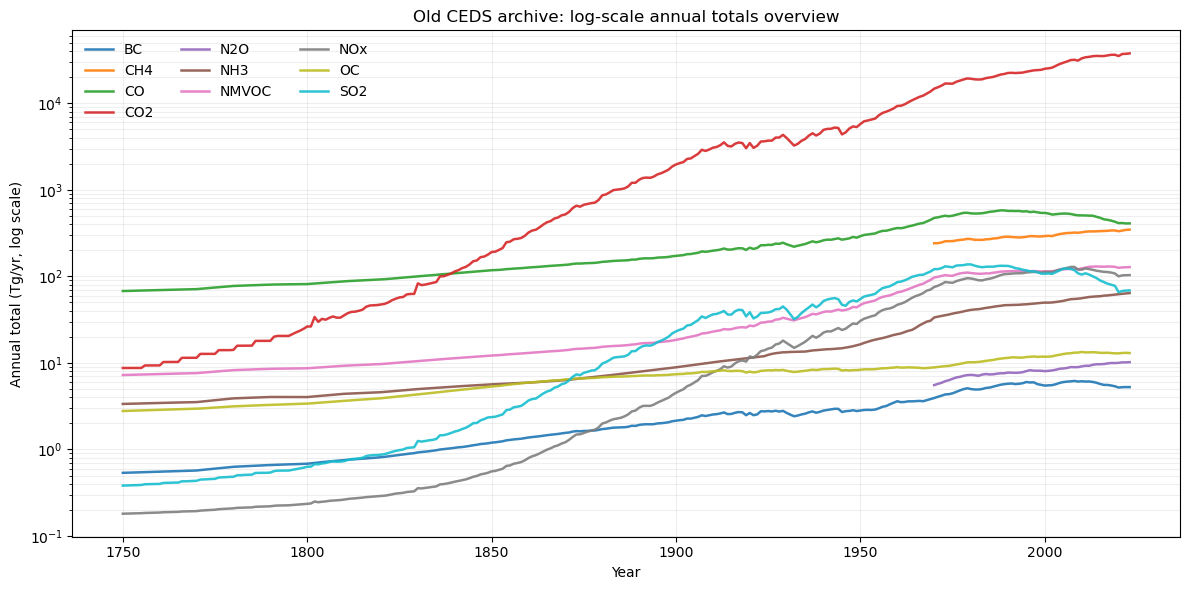

In [13]:
# Plot 2: log-scale overview to compare the historical magnitude across key species
fig, ax = plt.subplots(figsize=(12, 6))
for column in overview_series.columns:
    ax.plot(overview_series.index, overview_series[column], linewidth=1.8, alpha=0.9, label=column)
ax.set_yscale('log')
ax.set_title("Old CEDS archive: log-scale annual totals overview")
ax.set_xlabel("Year")
ax.set_ylabel("Annual total (Tg/yr, log scale)")
ax.grid(alpha=0.2, which='both')
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()


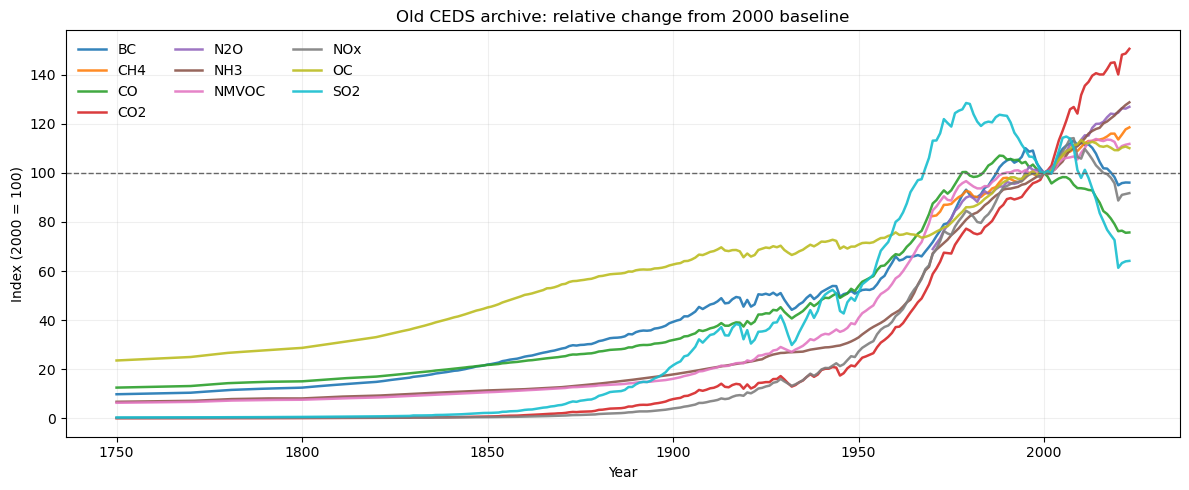

In [14]:
# Plot 3: relative change from the 2000 baseline for the key working species
overview_ref = overview_series.divide(overview_series.loc[2000]).mul(100)
fig, ax = plt.subplots(figsize=(12, 5))
for column in overview_ref.columns:
    ax.plot(overview_ref.index, overview_ref[column], linewidth=1.8, alpha=0.9, label=column)
ax.axhline(100, color='0.4', linestyle='--', linewidth=1)
ax.set_title("Old CEDS archive: relative change from 2000 baseline")
ax.set_xlabel("Year")
ax.set_ylabel("Index (2000 = 100)")
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()


In [15]:
# Quick summary table for the archive overview window
overview_summary = pd.DataFrame({
    "n_species": [len(overview_series.columns)],
    "year_min": [int(overview_series.index.min())],
    "year_max": [int(overview_series.index.max())],
    "annual_total_1750": [float(overview_series.loc[1750].sum()) if 1750 in overview_series.index else float('nan')],
    "annual_total_2023": [float(overview_series.loc[2023].sum()) if 2023 in overview_series.index else float('nan')],
})
print(overview_summary.to_string(index=False))


 n_species  year_min  year_max  annual_total_1750  annual_total_2023
        10      1750      2023          90.939663       38915.469653


In [17]:
overview_annual.to_csv("output/preliminary/old_ceds_baseline_overview_annual_totals.csv", index=False)

In [ ]:
## Quick intermediate cache

# Save a small set of derived tables so repeated exploratory analysis can start from the already-aggregated baseline.

from pathlib import Path

output_dir = PROJECT_ROOT / "output" / "preliminary"
output_dir.mkdir(parents=True, exist_ok=True)

# Save the main annual global totals for quick reuse.
annual_global = annual.rename(columns={"tg_per_year": "tg_yr"}).copy()
annual_global.to_csv(output_dir / "ceds_old_2000_2023_annual_global.csv", index=False)

# Save the species-summed annual totals for the standard quick analysis table.
global_totals.to_csv(output_dir / "ceds_old_2000_2023_key_species_global.csv", index=False)

# Save the normalized table so trend plots can be regenerated without reprocessing the gridded files.
normalized.reset_index().rename_axis("year").to_csv(output_dir / "ceds_old_2000_2023_normalized_index.csv", index=False)

# Save a lightweight summary for quick inspection in the notebook.
species_summary = pd.DataFrame({
    "n_files": [len(files)],
    "n_species": [len(global_totals["species_variable"].unique())],
    "year_min": [int(annual_global["year"].min())],
    "year_max": [int(annual_global["year"].max())],
})
species_summary.to_csv(output_dir / "ceds_old_2000_2023_summary.csv", index=False)

print(f"Saved annual outputs to {output_dir}")
print(species_summary.to_string(index=False))
